In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
shivanandmn_multilabel_classification_dataset_path = kagglehub.dataset_download('shivanandmn/multilabel-classification-dataset')

print('Data source import complete.')


100%|██████████| 11.4M/11.4M [00:02<00:00, 4.82MB/s]

Extracting files...


Data source import complete.


# Part 1：data preprocessing

Transform the original multi-label classification dataset into a format suitable for the T5 model. Specifically, we will concatenate the titles and abstracts of the articles into a single text input and merge multiple labels marked as 1 into a semicolon-separated string of labels. Ultimately, this preprocessing step will generate a clear text-to-text format, preparing for the training of the T5 model.

In [23]:
import pandas as pd

"""Prepare Data"""
input_csv = "train3.csv"
data = pd.read_csv(input_csv)
print(len(data))

# The previous logic for label_columns was incorrect based on the output, which showed
# `Index(['text', 'label'], dtype='object')` for `label_columns`. This implies `train3.csv`
# likely only has 'text' and 'label' columns, where 'label' should contain the target labels.
if 'label' in data.columns:
    # Convert labels to string type before assigning to 'labels' column
    data['labels'] = data['label'].astype(str).fillna('')
    print("Using 'label' column as target labels and converting to string type.")
else:
    # Fallback if 'label' column is not found. User would need to specify correct label columns.
    data['labels'] = '' # Default to empty string if no suitable label column. This will lead to issues.
    print("Warning: 'label' column not found in train3.csv. 'labels' column will be empty. Please check your CSV structure.")

data['text'] = data['text'].fillna('') # Ensure 'text' column has no NaNs
# Original code had: data['text'] = data['text'] + " " + data['ABSTRACT']
# Since 'ABSTRACT' was commented out, we assume it's not needed or not present in `train3.csv`.
# If 'ABSTRACT' column exists and needs to be concatenated, uncomment and modify this part.

print(data['labels'].head())
# Displaying the updated dataset
preprocessed_data = data[['text', 'labels']]
print(preprocessed_data.head())

# Save as a new CSV file
output_path = "preprocessed_data.csv"
preprocessed_data.to_csv(output_path, index=False)

299440
Using 'label' column as target labels and converting to string type.
0    6
1    6
2    8
3    4
4    6
Name: labels, dtype: object
                                                text labels
0                    i think about it i feel violent      6
1  i feel so grouchy a class post count link href...      6
2  i wonder if anyone is even looking at my mater...      8
3                      i still don t feel very funny      4
4                     im still feeling a bit grouchy      6


# Part 2：Model Training and Testing

This experiment still utilizes PyTorch and PyTorch Lightning as the experimental framework. Please refer to the official website for instructions on how to use PyTorch Lightning.

## Import the relevant packages.

In [5]:
import sys
!{sys.executable} -m pip install pytorch-lightning
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.data import DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint
from transformers import T5Tokenizer, T5ForConditionalGeneration, Trainer, TrainingArguments
from torch.optim import AdamW # Changed this line
from datasets import load_dataset
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import csv
import datasets

## 2.1 Custom Batch Processing Function

In [25]:
def collate_fn(batch):
    """
    Custom Batch Processing Function
    """
    texts = [str(item['text']) for item in batch] # Explicitly convert text to string
    labels = [str(item['labels']) for item in batch] # Explicitly convert labels to string
    # Encode text and labels using the tokenizer with a maximum length of 512.
    encoding = tokenizer(texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
    # Encode labels using the tokenizer directly.
    labels_encoding = tokenizer(labels, padding=True, truncation=True, max_length=512, return_tensors="pt")
    # Replace the pad token in the labels with -100, as required by the T5 model.
    labels_encoding["input_ids"][labels_encoding["input_ids"] == tokenizer.pad_token_id] = -100

    return {
        'input_ids': encoding['input_ids'],
        'attention_mask': encoding['attention_mask'],
        'labels': labels_encoding['input_ids']
    }

## 2.2 Custom Dataset

In [17]:
class T5Dataset(Dataset):
    """Custom Dataset"""

    def __init__(self, dataset):
        self.dataset = dataset

    def __getitem__(self, idx):
        item = self.dataset[idx]
        return {
            'text': item['text'],
            'labels': item['labels']
        }

    def __len__(self):
        return len(self.dataset)

## 2.3 Custom LightningModule

In [18]:
class T5FineTuner(pl.LightningModule):
    """Custom LightningModule"""

    def __init__(self, train_dataset, val_dataset, test_dataset, learning_rate=2e-5):
        super(T5FineTuner, self).__init__()
        self.validation_loss = []
        self.model = T5ForConditionalGeneration.from_pretrained('t5-small')
        self.learning_rate = learning_rate  # Fine-tuning
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.test_dataset = test_dataset
        self.prediction = []

    def forward(self, input_ids, attention_mask, labels=None):
        output = self.model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
        return output

    def configure_optimizers(self):
        return AdamW(self.model.parameters(), lr=self.learning_rate)

    def train_dataloader(self):
        train_loader = DataLoader(dataset=self.train_dataset, batch_size=batch_size, collate_fn=collate_fn,
                                  shuffle=True)
        return train_loader

    def val_dataloader(self):
        val_loader = DataLoader(dataset=self.val_dataset, batch_size=batch_size, collate_fn=collate_fn,
                                shuffle=False)
        return val_loader

    def test_dataloader(self):
        test_loader = DataLoader(dataset=self.test_dataset, batch_size=batch_size, collate_fn=collate_fn,
                                 shuffle=False)
        return test_loader

    def training_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']
        output = self(input_ids, attention_mask, labels)
        loss = output.loss
        self.log('train_loss', loss, prog_bar=True, logger=True, on_step=True, on_epoch=True)  # Output loss to console
        return loss

    def validation_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']
        output = self(input_ids, attention_mask, labels)
        loss = output.loss
        self.log('val_loss', loss, prog_bar=False, logger=True, on_step=True, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        self.model.eval()
        # Generate output sequences
        generated_ids = self.model.generate(input_ids=input_ids, attention_mask=attention_mask)
        # Convert generated token IDs to text
        generated_texts = [tokenizer.decode(generated_id, skip_special_tokens=True, clean_up_tokenization_spaces=True)
                           for generated_id in generated_ids]
        # Return decoded text
        # print(generated_texts)
        self.prediction.extend(generated_texts)

## 2.4 Model Training and Testing

In [27]:
def test(model, fast_run):
    trainer = pl.Trainer(fast_dev_run=fast_run)
    trainer.test(model)
    test_result = model.prediction
    # print(type(test_result))
    for text in test_result[:10]:
        print(text)
    return test_result


def train(fast_run):
    # Add callback for the best model
    checkpoint_callback = ModelCheckpoint(
        monitor='val_loss',  # Monitoring object is 'val_loss'
        dirpath='/kaggle/working/T5FineTuner_checkpoints',  # Path to save the model
        filename='Models-{epoch:02d}-{val_loss:.2f}',  # Name for the best model
        save_top_k=1,  # Save only the best one
        mode='min'  # When the monitored metric is minimum
    )
    # Set the path for logging
    log_dir = "/kaggle/working/log"
    logger = TensorBoardLogger(save_dir=log_dir, name="T5FineTuner_logs")
    trainer = pl.Trainer(max_epochs=epochs, log_every_n_steps=10, accelerator='cpu', devices="auto", fast_dev_run=fast_run,
                         callbacks=[checkpoint_callback], logger=logger)
    model = T5FineTuner(train_dataset, valid_dataset, test_dataset, learning_rate)
    trainer.fit(model)
    return model

## 2.5 Save Prediction Results

In [20]:
def save_to_csv(test_dataset, predictions, filename="test_predictions1.csv"):
    with open(filename, mode='w', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        writer.writerow(['text', 'true_labels', 'pred_labels'])

        for item, pred_label in zip(test_dataset, predictions):
            text = item['text']
            true_labels = item['labels']
            writer.writerow([text, true_labels, pred_label])

## 2.6 Start Task

In [ ]:
if __name__ == '__main__':
    # Define hyperparameters
    batch_size = 16
    epochs = 5
    learning_rate = 2e-5

    # data = load_dataset('csv', data_files={'train': '/kaggle/working/preprocessed_data.csv'})["train"]
    df_tmp = pd.read_csv('preprocessed_data.csv')
    data = datasets.Dataset.from_pandas(df_tmp)
    # Split dataset into training set and test+validation set
    train_testvalid = data.train_test_split(test_size=0.3, seed=42)
    # Split test+validation set into test set and validation set
    test_valid = train_testvalid['test'].train_test_split(test_size=0.5, seed=42)
    # Now we have training set, validation set, and test set
    train_dataset = train_testvalid['train']
    valid_dataset = test_valid['train']
    test_dataset = test_valid['test']
    # Print the size of each dataset
    print("Training set size:", len(train_dataset))
    print("Validation set size:", len(valid_dataset))
    print("Test set size:", len(test_dataset))
    # Prepare Dataset
    train_dataset = T5Dataset(train_dataset)
    valid_dataset = T5Dataset(valid_dataset)
    test_dataset = T5Dataset(test_dataset)
    # print(train_dataset.__len__())
    # print(train_dataset[0])

    # Initialize tokenizer
    tokenizer = T5Tokenizer.from_pretrained('t5-small')
    # Load DataLoader
    train_dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size,
                                  collate_fn=collate_fn, shuffle=True, drop_last=True)
    # Check loading status
    for i, batch in enumerate(train_dataloader):
        print(f"Batch {i + 1}")
        print("Input IDs:", batch['input_ids'])
        print("Input IDs shape:", batch['input_ids'].shape)
        print("Attention Mask:", batch['attention_mask'])
        print("Attention Mask shape:", batch['attention_mask'].shape)
        print("Labels:", batch['labels'])
        print("\n")
        if i == 0:
            break

    fast_run = False # Changed from True to False to enable full training
    model = train(fast_run)
#     model = T5FineTuner.load_from_checkpoint("Path",train_dataset=train_dataset, val_dataset=valid_dataset,test_dataset=test_dataset)
    pre_texts = test(model, fast_run)
    save_to_csv(test_dataset, pre_texts)

Epoch 0/4  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━ 12465/13101 11:44:53 • 0:36:33 0.29it/s v_num: 0.000 train_loss_step:   
                                                                                   0.000                           

In [ ]:
import os
import pandas as pd

file_name = 'test_predictions1.csv'

if os.path.exists(file_name):
    print(f"File '{file_name}' found. Displaying its head:")
    df_predictions = pd.read_csv(file_name)
    display(df_predictions.head())
else:
    print(f"File '{file_name}' not found.")

# Part 3：Model Evaluation

In [3]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np


def convert_labels(label_str):
    # Ensure label_str is a string before splitting
    label_str = str(label_str)
    return label_str.split(';') if label_str else []


def clean_label(label):
    return label.strip()


# Read the provided CSV file
file_path = "test_predictions1.csv"
data = pd.read_csv(file_path)
# print(data.head())

# Extract and convert the actual labels and predicted labels
true_labels = [convert_labels(label_str) for label_str in data['true_labels']]
pred_labels = [convert_labels(label_str) for label_str in data['pred_labels']]
# Recreate actual labels and predicted labels lists using cleaned labels
true_labels_cleaned = [list(map(clean_label, label_list)) for label_list in true_labels]
pred_labels_cleaned = [list(map(clean_label, label_list)) for label_list in pred_labels]


# Use MultiLabelBinarizer to one-hot encode the labels
mlb = MultiLabelBinarizer()
mlb.fit(true_labels_cleaned + pred_labels_cleaned)
y_true = mlb.transform(true_labels_cleaned)
y_pred = mlb.transform(pred_labels_cleaned)

print("Transformer(T5) Accuracy =", accuracy_score(y_true, y_pred))
print("Transformer(T5) Precision (micro-average) =", precision_score(y_true, y_pred, average='micro'))
print("Transformer(T5) Recall (micro-average) =", recall_score(y_true, y_pred, average='micro'))
print("Transformer(T5) F1 Score (micro-average) =", f1_score(y_true, y_pred, average='micro'))

print("\nAnother way to calculate accuracy:")
# Calculate accuracy for each column
column_accuracies = +np.mean(y_true == y_pred, axis=0)
# Add column names to each column accuracy
column_accuracy_with_labels = list(zip(mlb.classes_, column_accuracies))
# Calculate the mean of column accuracies
mean_column_accuracy = np.mean(column_accuracies)

for acc in column_accuracy_with_labels:
    print(acc)
# print(column_accuracy_with_labels)
print("Average accuracy = ", mean_column_accuracy)

FileNotFoundError: [Errno 2] No such file or directory: 'test_predictions1.csv'

In [6]:
combined_df_sorted_f1 = combined_df.sort_values(by='F1_micro', ascending=False)
display(combined_df_sorted_f1)

,Algorithms,Acc,F1_micro
4,Transformer(T5),0.6427,0.7916
3,LP(SVM),0.5914,0.7306
2,LP(RandomForest),0.5349,0.6470
1,CC(RandomForest),0.4787,0.6363
0,BR(RandomForest),0.4477,0.6149


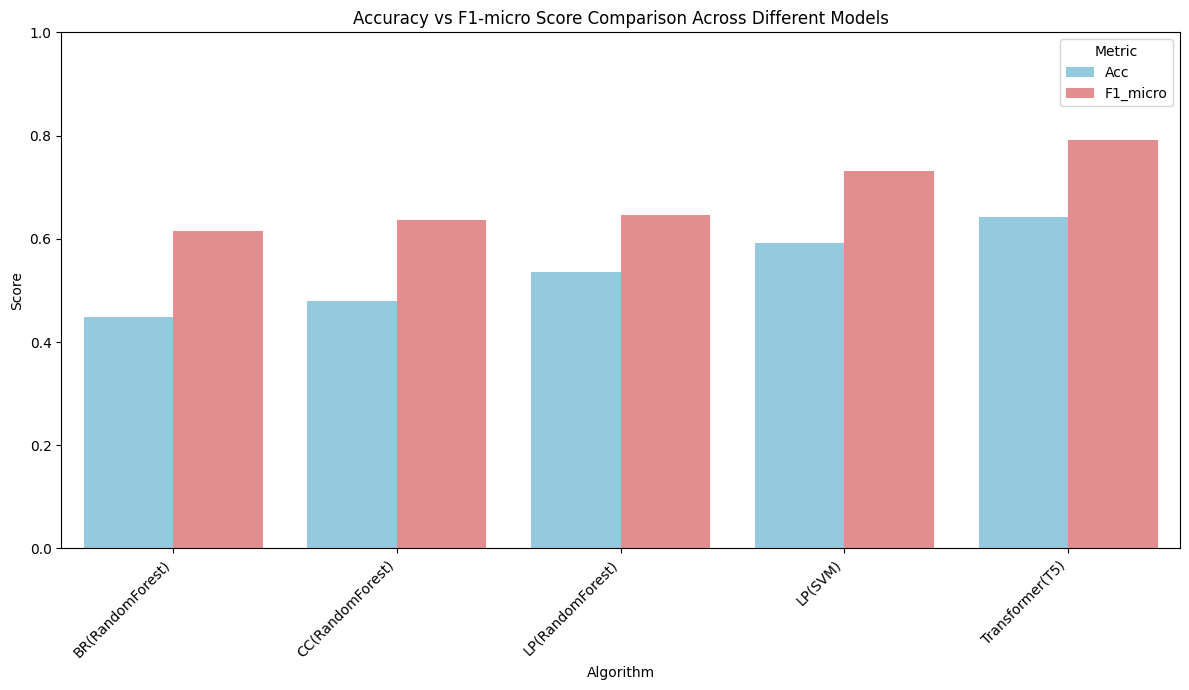

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_performance and df_f1_scores are already defined in the kernel state
# df_performance = pd.DataFrame(model_performance)
# df_f1_scores = pd.DataFrame(model_f1_scores)

# Merge the two dataframes on 'Algorithms'
combined_df = pd.merge(df_performance, df_f1_scores, on='Algorithms')

# Melt the dataframe to long format for grouped bar chart
melted_df = combined_df.melt(id_vars='Algorithms', var_name='Metric', value_name='Score')

# Create the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Algorithms', y='Score', hue='Metric', data=melted_df, palette={'Acc': 'skyblue', 'F1_micro': 'lightcoral'})
plt.title('Accuracy vs F1-micro Score Comparison Across Different Models')
plt.xlabel('Algorithm')
plt.ylabel('Score')
plt.ylim(0, 1) # Scores are between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd

# Data extracted from the markdown table in cell 3KC4EoOjv0gi
model_f1_scores = {
    'Algorithms': ['BR(RandomForest)', 'CC(RandomForest)', 'LP(RandomForest)', 'LP(SVM)', 'Transformer(T5)'],
    'F1_micro': [0.6149, 0.6363, 0.6470, 0.7306, 0.7916]
}

df_f1_scores = pd.DataFrame(model_f1_scores)
display(df_f1_scores)

,Algorithms,F1_micro
0,BR(RandomForest),0.6149
1,CC(RandomForest),0.6363
2,LP(RandomForest),0.6470
3,LP(SVM),0.7306
4,Transformer(T5),0.7916


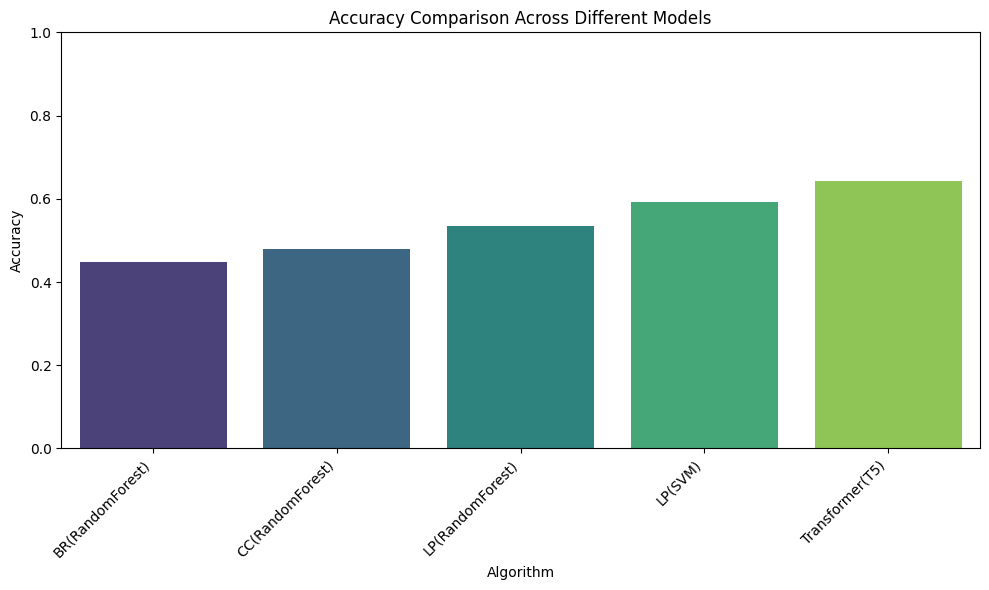

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data extracted from the markdown table in cell 3KC4EoOjv0gi
model_performance = {
    'Algorithms': ['BR(RandomForest)', 'CC(RandomForest)', 'LP(RandomForest)', 'LP(SVM)', 'Transformer(T5)'],
    'Acc': [0.4477, 0.4787, 0.5349, 0.5914, 0.6427]
}

df_performance = pd.DataFrame(model_performance)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Algorithms', y='Acc', data=df_performance, hue='Algorithms', palette='viridis', legend=False)
plt.title('Accuracy Comparison Across Different Models')
plt.xlabel('Algorithm')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Part 4：Experimental Results

This section summarizes and compares the results of various experiments conducted in the previous sections. We employed several algorithms to address the multi-label classification problem, including Binary Relevance (BR) combined with Random Forest, Classifier Chains (CC) combined with Random Forest, Label Powerset (LP) combined with Random Forest, LP combined with SVM, and the sequence generation method using the Transformer (T5) model.

By comparing the key performance metrics, including accuracy, micro-precision, micro-recall, and micro-F1 score, we found:

- The BR, CC, and LP methods based on Random Forest can achieve relatively good predictive performance.-
- Performance is further improved when LP is combined with SVM, especially in terms of recall and F1 score.
- Most notably, the Transformer (T5) model achieves the highest values in accuracy, recall and F1 score.

The specific numerical values are as follows:



| Algorithms       | Acc      | $Pre_{micro}$ | $Re_{micro}$ | $F1_{micro}$ |
| ---------------- | ---------- | ------------- | ------------ | ------------ |
| BR(RandomForest) | 0.4477     | **0.8038**    | 0.4978       | 0.6149       |
| CC(RandomForest) | 0.4787     | 0.8012        | 0.5277       | 0.6363       |
| LP(RandomForest) | 0.5349     | 0.7179        | 0.5889       | 0.6470       |
| LP(SVM)          | 0.5914     | 0.7368        | 0.7245       | 0.7306       |
| Transformer(T5)  | **0.6427** | 0.7994        | **0.7840**   | **0.7916**   |

From the results, we can conclude that the Transformer model demonstrates its powerful capability in handling complex multi-label classification tasks. This also indicates the wide-ranging potential and effectiveness of sequence-to-sequence models in the field of natural language processing (NLP).